# Tiny Transformer — An executable walkthrough

**For Edge AI students** — hands-on explanation inspired by Andrej Karpathy's "243-line GPT" article and the original
"Attention Is All You Need" paper.

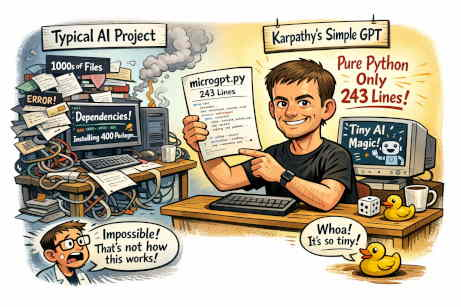

_Author: Juergen Kienhoefer_  
_Date: 2026-02-24_

---
**Sources:**

[Karpathy mini-GPT overview and walkthrough](https://www.towardsdeeplearning.com/andrej-karpathy-just-built-an-entire-gpt-in-243-lines-of-python-7d66cfdfa301)


## Learning objectives

1. Understand the motivation for the Transformer architecture (parallelism, attention).  
2. See scaled dot-product self-attention implemented in plain NumPy.  
3. Visualize attention weights for a toy sequence.  
4. Build a minimal Transformer block (attention + feed-forward) and run a forward pass.  
5. (Optional) Run a PyTorch micro-GPT snippet if PyTorch is available.

---

**How to use as slides:** This notebook includes slideshow metadata. Convert with:

`jupyter nbconvert transformer_tutorial.ipynb --to slides --post serve`

or use RISE / JupyterLab Presentation mode.

## Context & references

- Transformer implementations are big, require 400+ Python packages and complexity of keeping correct dependencies.
- Article overview: Andrej Karpathy's minimal GPT implementation demonstrates a compact, educative implementation that trains a character-level language model with zero external dependencies.  
- Foundational paper: Vaswani et al., **Attention Is All You Need** (2017) — introduces the Transformer architecture and scaled dot-product attention.  

**We'll implement the core math (scaled dot-product attention) in NumPy** so you can inspect every tensor and visualize how attention distributes weights across tokens.

---

In [ ]:
# Basic imports and helpers (NumPy + matplotlib)
import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
np.random.seed(42)

def softmax(x, axis=-1):
    # numerically stable softmax
    x_max = np.max(x, axis=axis, keepdims=True)
    e_x = np.exp(x - x_max)
    return e_x / np.sum(e_x, axis=axis, keepdims=True)

def positional_encoding(L, d_model):
    # simple sinusoidal positional encoding (from Vaswani et al.)
    pos = np.arange(L)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / (10000 ** (2*(i//2) / d_model))
    angle_rads = pos * angle_rates
    pe = np.zeros((L, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return pe

print('NumPy version:', np.__version__)
print('Positional encoding shape example:', positional_encoding(5, 8).shape)


NumPy version: 2.0.2
Positional encoding shape example: (5, 8)


## Positional Encoding Explained

Unlike Recurrent Neural Networks (RNNs) that process tokens sequentially, or Convolutional Neural Networks (CNNs) that capture local relationships through filters, the Transformer's attention mechanism processes all tokens in a sequence simultaneously. This parallelism is a major advantage for training speed, but it means the model inherently loses information about the order of tokens in the sequence. Without positional information, "cat sat on the mat" would be indistinguishable from "mat sat on the cat" in terms of token order.

To reintroduce this crucial sequential information, Transformers use **positional encoding**. This technique injects information about the relative or absolute position of tokens into the input embeddings. The `positional_encoding` function implemented above uses a sinusoidal method, as proposed by Vaswani et al. in "Attention Is All You Need". It generates a unique vector for each position in the sequence, which is then added to the token's embedding. This allows the model to differentiate between token positions, as each position has a distinct pattern of sine and cosine waves at different frequencies across the embedding dimensions. This periodic nature allows the model to easily learn relative positions.

### **Let's try an analogy**

Imagine you're trying to give each word in a sentence a unique 'address' that not only tells you where it is but also how far it is from other words. Instead of just numbering them 1, 2, 3, etc., which doesn't tell a Transformer much, we use a more sophisticated system.

Think of it like this: Each position in a sentence plays a **unique musical chord**. This chord isn't just one note; it's a combination of many notes played simultaneously. Some notes are low (slow frequency, long wavelength sine/cosine waves), and some are high (fast frequency, short wavelength sine/cosine waves). For each dimension of the positional encoding vector, we assign a specific frequency.

When you combine all these different 'notes' (the values from the sine and cosine functions at different frequencies), each position gets a chord that sounds distinctly different from its neighbors, yet shares harmonic relationships with them.

- **Uniqueness:** No two positions will have the exact same chord, because the combination of all those sine and cosine values at different frequencies will be unique for each position.
- **Relative Positioning:** Just like in music, two chords that are close together (e.g., position 1 and position 2) will sound more similar than two chords far apart (e.g., position 1 and position 10). The model can 'hear' or infer this relationship because the periodic nature of the sine and cosine waves means patterns repeat, but the combination of all frequencies at a given position creates a distinct signature.

So, the positional encoding creates a rich, continuous 'fingerprint' for each position, allowing the Transformer to understand the order and relative distance of words, which is crucial for language understanding.

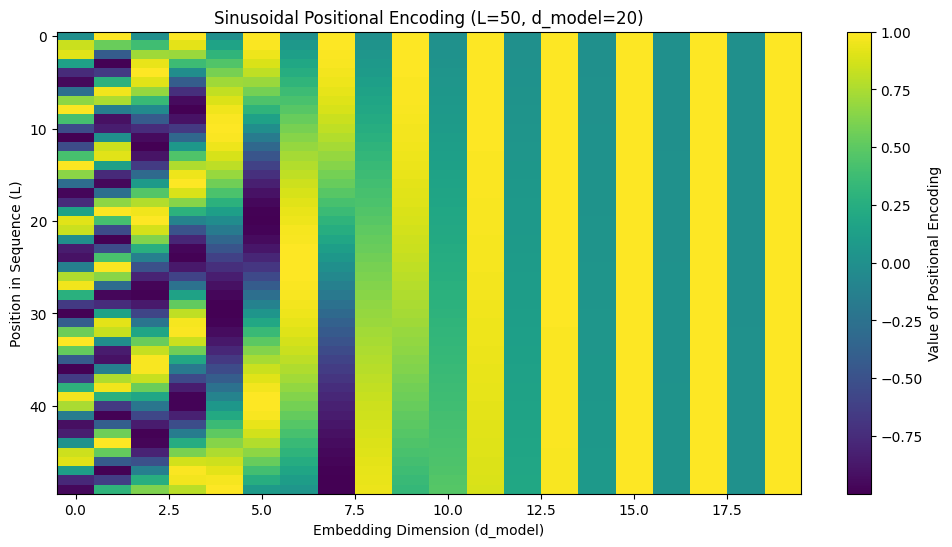

In [ ]:
# @title
import matplotlib.pyplot as plt
import numpy as np

def positional_encoding(L, d_model):
    # simple sinusoidal positional encoding (from Vaswani et al.)
    pos = np.arange(L)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / (10000 ** (2*(i//2) / d_model))
    angle_rads = pos * angle_rates
    pe = np.zeros((L, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return pe

# Parameters for visualization
L = 50  # Sequence length
d_model = 20  # Embedding dimension

# Generate positional encodings
pe = positional_encoding(L, d_model)

# Create the visualization
plt.figure(figsize=(12, 6))
plt.imshow(pe, cmap='viridis', aspect='auto')
plt.title('Sinusoidal Positional Encoding (L=50, d_model=20)')
plt.xlabel('Embedding Dimension (d_model)')
plt.ylabel('Position in Sequence (L)')
plt.colorbar(label='Value of Positional Encoding')
plt.show()


Now that your words have their "meaning" and their "position timestamp" combined into one vector, they enter the core engine of the Transformer: **Self-Attention**.

To understand *Queries, Keys, and Values*, forget about math for a second and think of a Flea Market or a Job Board.

## The Analogy: The Job Board

Imagine you are looking at a sentence, and every word in that sentence is a person visiting a professional networking event.

To find out how they relate to one another, every single word creates three things based on its combined (meaning + position) vector:

- A Query ($Q$): What the word is looking for. ("I am looking for a noun that describes a place.")
- A Key ($K$): What the word offers or who it is. ("I am a bank, which is a financial institution or a river edge.")
- A Value ($V$): The actual substance or content the word contributes once a match is made. ("Here is my deep semantic meaning.")

## The Interaction
- Step 1: Word A takes its Query and taps every other word on the shoulder, looking at their Keys.
- Step 2: The model multiplies the Query of Word A with the Keys of all other words. This is called a dot-product. If a Query and a Key match well, they get a high score.
- Step 3: These scores are turned into percentages (using a function called Softmax). For example, Word A might decide: "I am 80% interested in Word B, and 20% interested in Word C."
- Step 4: Word A multiplies those percentages by the Values ($V$) of Word B and Word C, and adds them together.

## The result?

Word A has now updated its meaning by pulling in the most relevant pieces of information from the words around it.

## Visualizing the Q, K, V Matrices

We can now show how a single input word vector is split into these three roles using simple linear algebra.

- **The Projection:** The combined input vector is multiplied by three separate weight matrices ($W_Q$, $W_K$, $W_V$). These matrices are learned during training. This creates three brand-new vectors for that word: $Q$, $K$, and $V$.

- **The Dimensions:** If your word vector has 512 dimensions, $Q$, $K$, and $V$ are typically smaller (like 64 dimensions each) because the Transformer uses "Multi-Head Attention" (running this process in parallel multiple times).

## Scaled dot-product self-attention (math recap)

Given query (Q), key (K), and value (V) matrices for a sequence of length *L*:

$$\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

## 1. The Matchmaking ($Q \times K$)
We multiply the matrix of all Queries ($Q$) by the matrix of all Keys ($K$). This creates a grid of raw attention scores showing how much every word cares about every other word.

## 2. The Scaling & Percentages ($\text{softmax}$)
We divide by a scaling factor ($\sqrt{d_k}$, just some math to keep numbers stable) and apply Softmax. This turns the raw scores into clean percentages that add up to 100% for each row.Example: If the sentence is "The bank of the river", the Query for "bank" looks at the Key for "river". The match is incredibly high. The software assigns an 85% attention weight to "river".

## 3. The Harvest ($\times V$)
Finally, we multiply these percentages by the Value ($V$) matrix.

Because "bank" attended heavily to "river", it pulls in a massive amount of the Value vector from "river". This context fundamentally changes the vector for "bank". It is no longer just a generic word; it transforms into a vector that specifically means "a bank near water".

## Summary

- We compute pairwise similarity scores between queries and keys.  
- Division by $\sqrt{d_k}$ stabilizes gradients.  
- Softmax turns scores into attention weights that sum to 1 for each query.

## Why did we need the Positional Encoding for this?

Without the positional encoding frequencies we talked about earlier, **the Keys and Queries wouldn't know where words are**.

If the sentence was "The cat chased the mouse" vs. "The mouse chased the cat", a Transformer without positional encoding would calculate the exact same attention scores. The Query for "chased" would match "cat" and "mouse" identically in both sentences.

Because the positional vectors were added at the very beginning, the Keys for "cat" in sentence one say *"I am a cat at Position 1"*, and in sentence two say *"I am a cat at Position 5"*. The Query for "chased" can now use that geometric distance to figure out exactly who did the chasing!

---

Below: a NumPy implementation and a visualization for a toy sequence.

Output shape: (5, 8)
Attention weights shape: (5, 5)


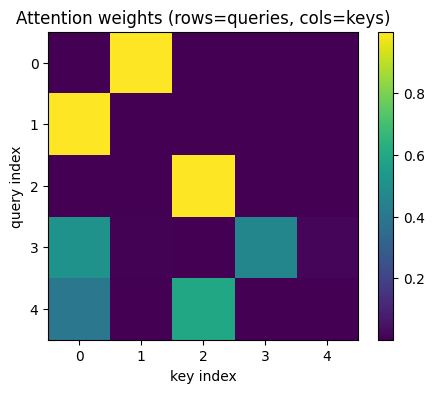

In [ ]:
# Tiny scaled dot-product attention in pure NumPy
def scaled_dot_product_attention(Q, K, V, mask=None):
    # Q, K, V: (L, d_k) for a single head; we will implement single-head attention here
    d_k = Q.shape[-1]
    scores = Q @ K.T            # (L, L)
    scores = scores / math.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores, axis=-1)  # (L, L)
    out = weights @ V           # (L, d_k)
    return out, weights

# Toy example: 5 tokens, embedding dim 8
L = 5
d = 8
# create random token embeddings (in practice, token embeddings come from a lookup table)
X = np.random.randn(L, d)
# linear projections (random init for demo)
Wq = np.random.randn(d, d)
Wk = np.random.randn(d, d)
Wv = np.random.randn(d, d)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

out, weights = scaled_dot_product_attention(Q, K, V)

print('Output shape:', out.shape)
print('Attention weights shape:', weights.shape)

# Visualize attention weights as a heatmap
plt.figure(figsize=(5,4))
plt.imshow(weights, aspect='auto')
plt.title('Attention weights (rows=queries, cols=keys)')
plt.xlabel('key index')
plt.ylabel('query index')
plt.colorbar()
plt.show()


## Transformer Block

Now that you know how words get their timestamps (positional encoding) and how they **talk to each other** (Query, Key, Value Attention), we can zoom out to the structure that houses this entire process: **The Transformer Block**.

In a decoder-style model (like GPT), this block repeats over and over (e.g., 12 times in GPT-2, 96 times in GPT-3).

To keep it simple, let's look at a *Minimal Transformer Block* containing just one single attention head, a layer norm, and a feed-forward network.

## The Analogy: The Corporate Strategy Assembly Line

Think of a single Transformer block as a specialized **Department Corporate Retreat**.

Before entering the room, every employee (*word vector*) has their job title and ID badge (*meaning + position*). The block is an assembly line with two distinct phases:

- **The Collaboration Phase** (Attention) and The
- **Individual Reflection Phase** (Feed-Forward).

##Step 1: The Collaboration Phase (Self-Attention)

The employees walk into the room. This is the exact Job Board / Flea Market scenario we just discussed.

- **What happens**: Every word sends out its **Query**, checks everyone else's **Keys**, and pulls in relevant **Values**.

- **The Goal:** Contextual awareness. The word "bank" looks at the rest of the sentence and realizes, *"Ah, there is a fishing rod nearby, I am a river bank."*

## Step 2: The Safety Net & Reality Check (Add & LayerNorm)

This is where the architecture introduces a brilliant engineering trick: the **Residual Connection** (the "Add" step) and Layer Normalization.

## The "Add" Step (Residual Connection)

Imagine if, during the collaboration phase, a dominant word completely shouted down a quieter word, causing the quieter word to lose its original identity entirely. To prevent this, the Transformer uses a *bypass lane*.

We take the word's original incoming vector, skip the attention phase entirely, and **add it back** to the output of the attention phase.

- **The Analogy:** At the end of the meeting, the boss says, *"Before we adopt these new ideas, write them down on your original notepad so you don't forget who you were when you walked in."* This keeps the model stable and prevents vital information from getting lost in deep networks.

## The "LayerNorm" Step

After adding them together, we normalize the numbers.

- **The Analogy:** A moderator steps in and calibrates everyone's volume. If one employee is shouting at a 100 and another is whispering at a 1, LayerNorm scales their vector numbers so everyone is speaking at a steady, mathematically stable volume (a mean of 0 and variance of 1). This stops the AI's numbers from exploding.

## Step 3: The Individual Reflection Phase (Feed-Forward Network)

Now that the words have successfully shared information, they move to the **Feed-Forward Network (FFN)**.

The FFN is just two standard linear layers with a non-linear activation function (like ReLU or GELU) in the middle.

Crucially, the words do not talk to each other during this step. Each word vector goes through this exact same mini-network completely in isolation.

- **Layer 1 (Expansion):** The vector is projected into a much larger space (usually 4x larger, like expanding 512 dimensions to 2048).

- **Non-linearity (The Filter):** A function like ReLU drops any negative numbers to zero.

- **Layer 2 (Contraction):** The vector is squeezed back down to its original size (512 dimensions).

## The Analogy: The Single-Person Study Cubicle

After the massive group brainstorming session, every employee is sent to their own isolated study cubicle.

They are handed a massive worksheet (the 4x expansion) to process the new insights they just learned from the group. The worksheet asks tough, non-linear questions (the activation function) to filter out noise. Once they finish processing, they pack their notes back down into their standard briefcase (shrinking back to 512 dimensions).


## Step 4: The Final Reality Check (Another Add & LayerNorm)

Just like before, we take the vector from *before* the study cubicle, skip the cubicle, and add it to the output of the cubicle (Residual Connection). Then, we normalize the volume one last time (LayerNorm).

## The Big Picture: Why this loop works

When a sentence passes through this single block, the words follow a strict rhythm:

  1. Talk to each other to gather context (Attention).

  2. Combine and normalize so we don't lose our minds (Add & Norm).

  3. Go to a private cubicle to think deeply about that context (Feed-Forward).

  4. Combine and normalize again (Add & Norm).

By the time the vectors exit the top of the block, they are significantly smarter. They enter the next block, where the exact same process happens all over again, allowing the model to build incredibly deep, abstract understandings of human language.

## Minimal Transformer block

A Transformer block (decoder-style, as in GPT) contains:

1. Self-attention (multi-head, but we'll show single-head).  
2. Add & LayerNorm (residual connection).  
3. Position-wise feed-forward network (two linear layers + nonlinearity).  

We implement a simplified version (single head, simple layernorm) to keep things transparent.

In [ ]:
# Simple LayerNorm implementation
def layer_norm(x, eps=1e-5):
    mu = x.mean(axis=-1, keepdims=True)
    sigma = x.std(axis=-1, keepdims=True)
    return (x - mu) / (sigma + eps)

# Feed-forward network
def feed_forward(x, d_ff):
    # x: (L, d)
    W1 = np.random.randn(x.shape[-1], d_ff) / math.sqrt(x.shape[-1])
    b1 = np.zeros(d_ff)
    W2 = np.random.randn(d_ff, x.shape[-1]) / math.sqrt(d_ff)
    b2 = np.zeros(x.shape[-1])
    h = np.maximum(0, x @ W1 + b1)  # ReLU
    return h @ W2 + b2

def transformer_block(x):
    # x: (L, d)
    # Self-attention (single head)
    d = x.shape[-1]
    Wq = np.random.randn(d, d) / math.sqrt(d)
    Wk = np.random.randn(d, d) / math.sqrt(d)
    Wv = np.random.randn(d, d) / math.sqrt(d)
    Q = x @ Wq
    K = x @ Wk
    V = x @ Wv
    attn_out, _ = scaled_dot_product_attention(Q, K, V)
    x = x + attn_out            # residual
    x = layer_norm(x)
    # feed-forward
    ff = feed_forward(x, d_ff=4*d)
    x = x + ff
    x = layer_norm(x)
    return x

# Run forward pass
X_in = np.random.randn(L, d)
X_out = transformer_block(X_in)
print('Transformer block input shape:', X_in.shape)
print('Transformer block output shape:', X_out.shape)


NameError: name 'np' is not defined

## How this connects to Karpathy's tiny GPT

- Karpathy's 243-line implementation is a compact, pedagogical reimplementation of a decoder-only Transformer (GPT-like).  
- It stitches together token embeddings, positional encodings, one or a few transformer blocks, and an output linear layer to predict next tokens.  
- The notebook above reproduces the *core math* (attention + feed-forward) in a lightweight, dependency-free form so you can step through tensors.

**Next:** optional PyTorch micro-GPT snippet (will run only if PyTorch is installed).

In [ ]:
# Optional: tiny PyTorch decoder-only block (runs only if torch is available)
try:
    import torch
    import torch.nn as nn
    class TinyBlock(nn.Module):
        def __init__(self, d_model):
            super().__init__()
            self.attn = nn.MultiheadAttention(d_model, num_heads=2, batch_first=True)
            self.ln1 = nn.LayerNorm(d_model)
            self.ff = nn.Sequential(nn.Linear(d_model, 4*d_model),
                                    nn.ReLU(),
                                    nn.Linear(4*d_model, d_model))
            self.ln2 = nn.LayerNorm(d_model)
        def forward(self, x):
            # x: (batch, seq, d_model)
            attn_out, weights = self.attn(x, x, x, need_weights=True)
            x = x + attn_out
            x = self.ln1(x)
            x = x + self.ff(x)
            x = self.ln2(x)
            return x, weights

    print('Torch detected, running tiny PyTorch block demo...')
    d_model = 16
    seq_len = 6
    block = TinyBlock(d_model)
    x = torch.randn(1, seq_len, d_model)
    out, w = block(x)
    print('Output shape (torch):', out.shape)
    # show attention weights for head 0 as numpy
    w_np = w.detach().numpy()  # shape (batch*num_heads, seq, seq) in PyTorch's MultiheadAttention older versions
    print('Attention weights available with shape:', w_np.shape)
except Exception as e:
    print('PyTorch not available in this environment or an error occurred:', e)
    print('If you want to run the PyTorch demo, install torch: pip install torch --index-url https://download.pytorch.org/whl/cpu')


Torch detected, running tiny PyTorch block demo...
Output shape (torch): torch.Size([1, 6, 16])
Attention weights available with shape: (1, 6, 6)


## Exercises (for students)

1. Replace the random projections with trainable parameters and implement a tiny training loop on a toy next-token task (e.g., sequence copying or tiny dataset like a list of names).  
2. Extend single-head attention to multi-head attention and visualize each head's weights.  
3. Modify the positional encoding to use learned positional embeddings and compare model behaviour.  
4. Try Karpathy's original repo (see below) and compare the minimal PyTorch version to this NumPy walk-through.

---

**Instructor notes:** This notebook intentionally uses random initialization for clarity. For teaching, step through each cell and display intermediate tensors to show shapes and numerical ranges.

# **First, What Is This Thing Actually Doing?**

Before we touch the code, let’s be clear about what microGPT does. It downloads a list of baby names. It learns the patterns in those names. Then it generates new, fake names that sound real but never existed.

That’s it. Same concept as ChatGPT, just tiny. ChatGPT learned from the entire internet. This model learns from a text file of names. But the algorithm is identical. The attention mechanism, the training loop, the way it predicts the next token: it’s the same math running inside GPT-4. Just at a micro scale.

Think of it like this: a toy car and a Tesla both have engines, wheels, steering, and brakes. The toy car won’t win any races, but if you want to understand how a car works, the toy car is perfect.

## Part 1: The Tokenizer (Lines You’ll Forget Are Important)

In [ ]:
chars = ['<BOS>', '<EOS>'] + sorted(list(set(''.join(docs))))
vocab_size = len(chars)
stoi = { ch:i for i, ch in enumerate(chars) }
itos = { i:ch for i, ch in enumerate(chars) }

Computers don’t understand letters. They understand numbers.

So the very first job is to convert every character into a number. The letter a becomes 2, b becomes 3, and so on. There are also two special tokens: <BOS> (Beginning Of Sequence, "Hey model, a new name is starting!") and <EOS> (End Of Sequence "This name is done now!").

stoi converts strings to integers. itos converts integers back to strings. That's your entire tokenizer.

ChatGPT uses a much fancier tokenizer called BPE (Byte Pair Encoding) that groups common letter combinations into single tokens. But the idea is identical: text in, numbers out.

## Part 2: The Autograd Engine (The Heart of Everything)

This is where it gets beautiful.

In [ ]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)

Karpathy builds a mini version of PyTorch’s autograd engine in about 40 lines.

**Let me explain why this matters.**

When a neural network makes a prediction, it’s usually wrong at first. We need to figure out: *which numbers (weights) should we adjust, and by how much, to make it less wrong?*

That’s what backpropagation does. And backpropagation needs gradients — basically, it needs to know *“if I wiggle this weight a tiny bit, how much does the final error change?”*

The `Value` class wraps every single number in the network and tracks:

   - `data`: the actual number
   - `grad`: how much the final loss changes when you change this number
   - `_backward`: instructions for computing that gradient
   - `_prev`: which other Values were used to create this one

Every time you do math (add, multiply, power, etc.), the `Value` class quietly builds a graph of operations behind the scenes. When training is done for one example, you call `.backward()` and the gradients flow back through this graph automatically.

**Here's the addition:**

In [ ]:
def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')
    def _backward():
        self.grad += out.grad
        other.grad += out.grad
    out._backward = _backward
    return out

If `c = a + b`, and someone tells you *"c's gradient is 5,"* then both a's and b's gradient is also 5. Because if you increase `a` by 1, `c` also increases by 1. That's the chain rule from calculus, implemented in 4 lines.

Multiplication is similar but uses the *“swap”* rule:

In [ ]:
def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
    out._backward = _backward
    return out

If `c = a * b`, then a's gradient is `b * (gradient of c)` and b's gradient is `a * (gradient of c)`. That's it.

The full backward pass uses **topological sort**: it just makes sure you compute gradients in the right order (outputs first, inputs last):

In [ ]:
def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)
    build_topo(self)
    self.grad = 1
    for v in reversed(topo):
        v._backward()

This is literally the same algorithm that runs inside PyTorch when you call `loss.backward()`. Karpathy just wrote it from scratch using Python lists and recursion.

## **Part 3: Model Parameters (The “Brain” of the GPT)**

In [ ]:
matrix = lambda nout, nin, std=0.02: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd)}

Every neural network is just a collection of numbers (called **weights** or **parameters**). Before training, these are random. After training, they encode learned patterns.

Here’s what each weight matrix does:

   - `wte` (Word Token Embedding): Converts each token ID into a vector of 16 numbers. Think of it as giving each character a "personality": a position in a 16-dimensional space where similar characters end up close together.
  -  `wpe` (Word Position Embedding): Tells the model where in the sequence each character sits. "a" at position 1 should be treated differently than "a" at position 5.

For each transformer layer, there are:

   - `attn_wq, attn_wk, attn_wv`: The Query, Key, and Value matrices for attention (more on this below)
   - `attn_wo`: The output projection of attention
   - `mlp_fc1, mlp_fc2`: The feedforward network that processes the attended information

**Default configuration**: 16 embedding dimensions, 4 attention heads, 1 layer, sequence length of 8. This gives you roughly **4,000 parameters**. GPT-4 has over a trillion. Same architecture, wildly different scale.


## **Part 4: The GPT Architecture (Where the Magic Happens)**

This is the core. Let me break down the `gpt()` function piece by piece.

### Step 1: Embedding

In [ ]:
tok_emb = state_dict['wte'][token_id]
pos_emb = state_dict['wpe'][pos_id % block_size]
x = [t + p for t, p in zip(tok_emb, pos_emb)]

Take the character’s embedding. Take the position’s embedding. Add them together. Now the model knows both what the character is and where it sits.

### Step 2: RMSNorm

In [ ]:
def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

Before each major computation, we normalize the values so they don’t explode or shrink to zero. RMSNorm is a simpler cousin of LayerNorm (which original GPT-2 uses). It divides each value by the root-mean-square of all values.

Think of it as keeping everyone’s volume at a reasonable level before a group discussion.

### Step 3: Attention (The Star of the Show)

This is the part everyone talks about. “Attention is All You Need”: the famous 2017 paper. Here it is, naked, in pure Python:

In [ ]:
q = linear(x, state_dict[f'layer{li}.attn_wq'])
k = linear(x, state_dict[f'layer{li}.attn_wk'])
val = linear(x, state_dict[f'layer{li}.attn_wv'])

For the current token, compute three things:

   - `Query (Q)`: *“What am I looking for?”*
   - `Key (K)`: *“What do I contain?”*
   - `Value (V)`: *“What information do I carry?”*

Then for each attention head:

In [ ]:
attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5
               for t in range(len(k_h))]
attn_weights = softmax(attn_logits)
head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h)))
            for j in range(head_dim)]

Here’s what’s happening in plain English:

   1. The current token’s Query asks: “Which previous tokens are relevant to me?”
   2. It computes a dot product with every previous token’s Key (like a compatibility score)
   3. These scores are passed through softmax (making them add up to 1, like probabilities)
   4. The Value vectors of all tokens are then mixed together, weighted by these scores

So if the model is generating the name **“Micha”** and it’s about to predict the next letter, the attention mechanism lets the current position *“look back”* at M, i, c, h, and a, and decide which ones matter most for predicting what comes next.

The division by `head_dim**0.5` is called **scaled attention**: it prevents the dot products from getting too large, which would make softmax output extreme probabilities (basically all 0s and one 1).

**Multi-head attention** means we run this process 4 times in parallel (with 4 different Q, K, V projections), each looking at a different 4-dimensional slice of the 16-dimensional embedding. One head might learn to focus on vowels. Another might focus on recent characters. They all bring different perspectives.

### Step 4: Residual Connection

In [ ]:
x = [a + b for a, b in zip(x, x_residual)]

After attention, we add back the original input. This is called a residual connection (or skip connection).

Why? Because it creates a **“highway”** for gradients during training. Without it, deep networks become nearly impossible to train. It’s like saying: “Whatever you learned from attention, just add it to what you already knew.”

###Step 5: MLP (Feed-Forward Network)

In [ ]:
x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
x = [xi.relu() ** 2 for xi in x]
x = linear(x, state_dict[f'layer{li}.mlp_fc2'])

After attention decides which tokens to pay attention to, the MLP processes that information.

The MLP expands the 16-dimensional vector to 64 dimensions (4 * n_embd), applies a non-linearity (squared ReLU), and squishes it back to 16.

Why expand and compress? Think of it like brainstorming. You first generate lots of ideas (expand to 64), filter out the bad ones (ReLU kills negatives, squaring amplifies strong signals), then summarize (compress back to 16).

**Squared ReLU** instead of GELU is one of Karpathy’s simplifications. Regular ReLU says: **“if negative, make it 0.”** Squared ReLU says: **“if negative, make it 0; if positive, square it.”** This gives stronger non-linearity.

### Step 6: Project to Vocabulary



In [ ]:
logits = linear(x, state_dict['wte'])

Finally, the model uses the same embedding matrix `(wte)` to project back to vocabulary size. This is called **weight tying**, the same weights that convert token IDs into embeddings are reused to convert embeddings back into predictions.

The output is a score for each possible next character. *Higher score = model thinks this character is more likely to come next*.

### Part 5: The Training Loop (How It Learns)

In [ ]:
for step in range(args.num_steps):
    doc = docs[step % len(docs)]
    tokens = [BOS] + [stoi[ch] for ch in doc] + [EOS]
    tokens = tokens[:block_size]

For each step, grab one name from the dataset. Convert it to token IDs. Add BOS at the start and EOS at the end.

In [ ]:
for pos_id in range(len(tokens) - 1):
    logits = gpt(tokens[pos_id], pos_id, keys, values)
    probs = softmax(logits)
    loss = -probs[tokens[pos_id + 1]].log()

For each position, the model sees the current token and predicts the next one. The loss is **negative log likelihood**: if the model assigns high probability to the correct next character, the loss is low. If it assigns low probability, the loss is high.

Then `loss.backward()` computes gradients for every parameter, and the **Adam optimizer** updates them:

In [ ]:
m[i] = beta1 * m[i] + (1 - beta1) * p.grad
v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
m_hat = m[i] / (1 - beta1 ** (step + 1))
v_hat = v[i] / (1 - beta2 ** (step + 1))
p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)

Adam is like gradient descent with memory. Instead of just following the current gradient, it tracks:

   - `m`: the average direction of recent gradients (momentum: like a ball rolling downhill)
   - `v`: the average magnitude of recent gradients (helps normalize: big gradients don't dominate)

*This is the same optimizer used to train GPT-4, DALL-E, and every major model today.*

### Part 6: Inference (Generating New Names)

In [ ]:
for sample_idx in range(5):
    token_id = BOS
    generated = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == EOS:
            break
        generated.append(itos[token_id])

Start with BOS. Ask the model “what comes next?” Sample from the probability distribution. Feed that prediction back in. Repeat until the model outputs EOS or we run out of space.

This is **autoregressive generation**: the same thing ChatGPT does every time you send it a message. One token at a time, each conditioned on everything before it.

### The Big Picture: Why This Matters

Here’s the thing that blew my mind.

Every line of code beyond these 243 lines: the thousands of files in PyTorch, the CUDA kernels, the distributed training frameworks, the fancy tokenizers, **all of that is just optimization**. Making it faster. Making it bigger. Making it run across thousands of GPUs.

But the *algorithm*? The actual intelligence? It’s right here.

As Karpathy put it: *“This is the full algorithmic content of what is needed. Everything else is just for efficiency. I cannot simplify this any further.”*

**This is Karpathy’s 6-year compression journey:**

   - 2020: micrograd (autograd engine)
   - 2020: minGPT (PyTorch GPT)
   - 2023: nanoGPT (production-grade training)
   - 2024: llm.c (raw C/CUDA, no frameworks)
   - 2026: microGPT (the algorithm and nothing else)

Each step peeled away a layer of abstraction. This final version removed all of them.

The industry is spending $400 billion on AI infrastructure this year. But the core algorithm that powers all of it? It fits in a file smaller than most README documents.

**If you’re trying to understand how LLMs work, don’t start with the PyTorch documentation. Start here!**

### **And here is the full clode**

In [ ]:
"""
The most atomic way to train and run inference for a GPT in pure, dependency-free Python.
This file is the complete algorithm.
Everything else is just efficiency.

@karpathy
"""

import os       # os.path.exists
import math     # math.log, math.exp
import random   # random.seed, random.choices, random.gauss, random.shuffle
random.seed(42) # Let there be order among chaos

#from google.colab import drive
#drive.mount('/content/drive')

# Let there be a Dataset `docs`: list[str] of documents (e.g. a list of names)
NAMES_FILE = ""# os.path.join('drive', 'MyDrive', 'Notebooks', 'names.txt')
if not os.path.exists(NAMES_FILE):
    import urllib.request
    names_url = 'https://raw.githubusercontent.com/karpathy/makemore/988aa59/names.txt'
    urllib.request.urlretrieve(names_url, 'input.txt')
docs = [line.strip() for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")

# Let there be a Tokenizer to translate strings to sequences of integers ("tokens") and back
uchars = sorted(set(''.join(docs))) # unique characters in the dataset become token ids 0..n-1
BOS = len(uchars) # token id for a special Beginning of Sequence (BOS) token
vocab_size = len(uchars) + 1 # total number of unique tokens, +1 is for BOS
print(f"vocab size: {vocab_size}")

# Let there be Autograd to recursively apply the chain rule through a computation graph
class Value:
    __slots__ = ('data', 'grad', '_children', '_local_grads') # Python optimization for memory usage

    def __init__(self, data, children=(), local_grads=()):
        self.data = data                # scalar value of this node calculated during forward pass
        self.grad = 0                   # derivative of the loss w.r.t. this node, calculated in backward pass
        self._children = children       # children of this node in the computation graph
        self._local_grads = local_grads # local derivative of this node w.r.t. its children

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data + other.data, (self, other), (1, 1))

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return Value(self.data * other.data, (self, other), (other.data, self.data))

    def __pow__(self, other): return Value(self.data**other, (self,), (other * self.data**(other-1),))
    def log(self): return Value(math.log(self.data), (self,), (1/self.data,))
    def exp(self): return Value(math.exp(self.data), (self,), (math.exp(self.data),))
    def relu(self): return Value(max(0, self.data), (self,), (float(self.data > 0),))
    def __neg__(self): return self * -1
    def __radd__(self, other): return self + other
    def __sub__(self, other): return self + (-other)
    def __rsub__(self, other): return other + (-self)
    def __rmul__(self, other): return self * other
    def __truediv__(self, other): return self * other**-1
    def __rtruediv__(self, other): return other * self**-1

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._children:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1
        for v in reversed(topo):
            for child, local_grad in zip(v._children, v._local_grads):
                child.grad += local_grad * v.grad

# Initialize the parameters, to store the knowledge of the model
n_layer = 1     # depth of the transformer neural network (number of layers)
n_embd = 16     # width of the network (embedding dimension)
block_size = 16 # maximum context length of the attention window (note: the longest name is 15 characters)
n_head = 4      # number of attention heads
head_dim = n_embd // n_head # derived dimension of each head
matrix = lambda nout, nin, std=0.08: [[Value(random.gauss(0, std)) for _ in range(nin)] for _ in range(nout)]
state_dict = {'wte': matrix(vocab_size, n_embd), 'wpe': matrix(block_size, n_embd), 'lm_head': matrix(vocab_size, n_embd)}
for i in range(n_layer):
    state_dict[f'layer{i}.attn_wq'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wk'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wv'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.attn_wo'] = matrix(n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc1'] = matrix(4 * n_embd, n_embd)
    state_dict[f'layer{i}.mlp_fc2'] = matrix(n_embd, 4 * n_embd)
params = [p for mat in state_dict.values() for row in mat for p in row] # flatten params into a single list[Value]
print(f"num params: {len(params)}")

# Define the model architecture: a function mapping tokens and parameters to logits over what comes next
# Follow GPT-2, blessed among the GPTs, with minor differences: layernorm -> rmsnorm, no biases, GeLU -> ReLU
def linear(x, w):
    return [sum(wi * xi for wi, xi in zip(wo, x)) for wo in w]

def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def rmsnorm(x):
    ms = sum(xi * xi for xi in x) / len(x)
    scale = (ms + 1e-5) ** -0.5
    return [xi * scale for xi in x]

def gpt(token_id, pos_id, keys, values):
    tok_emb = state_dict['wte'][token_id] # token embedding
    pos_emb = state_dict['wpe'][pos_id] # position embedding
    x = [t + p for t, p in zip(tok_emb, pos_emb)] # joint token and position embedding
    x = rmsnorm(x) # note: not redundant due to backward pass via the residual connection

    for li in range(n_layer):
        # 1) Multi-head Attention block
        x_residual = x
        x = rmsnorm(x)
        q = linear(x, state_dict[f'layer{li}.attn_wq'])
        k = linear(x, state_dict[f'layer{li}.attn_wk'])
        v = linear(x, state_dict[f'layer{li}.attn_wv'])
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            hs = h * head_dim
            q_h = q[hs:hs+head_dim]
            k_h = [ki[hs:hs+head_dim] for ki in keys[li]]
            v_h = [vi[hs:hs+head_dim] for vi in values[li]]
            attn_logits = [sum(q_h[j] * k_h[t][j] for j in range(head_dim)) / head_dim**0.5 for t in range(len(k_h))]
            attn_weights = softmax(attn_logits)
            head_out = [sum(attn_weights[t] * v_h[t][j] for t in range(len(v_h))) for j in range(head_dim)]
            x_attn.extend(head_out)
        x = linear(x_attn, state_dict[f'layer{li}.attn_wo'])
        x = [a + b for a, b in zip(x, x_residual)]
        # 2) MLP block
        x_residual = x
        x = rmsnorm(x)
        x = linear(x, state_dict[f'layer{li}.mlp_fc1'])
        x = [xi.relu() for xi in x]
        x = linear(x, state_dict[f'layer{li}.mlp_fc2'])
        x = [a + b for a, b in zip(x, x_residual)]

    logits = linear(x, state_dict['lm_head'])
    return logits

# Let there be Adam, the blessed optimizer and its buffers
learning_rate, beta1, beta2, eps_adam = 0.01, 0.85, 0.99, 1e-8
m = [0.0] * len(params) # first moment buffer
v = [0.0] * len(params) # second moment buffer

# Repeat in sequence
num_steps = 1000 # number of training steps
for step in range(num_steps):

    # Take single document, tokenize it, surround it with BOS special token on both sides
    doc = docs[step % len(docs)]
    tokens = [BOS] + [uchars.index(ch) for ch in doc] + [BOS]
    n = min(block_size, len(tokens) - 1)

    # Forward the token sequence through the model, building up the computation graph all the way to the loss
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    losses = []
    for pos_id in range(n):
        token_id, target_id = tokens[pos_id], tokens[pos_id + 1]
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax(logits)
        loss_t = -probs[target_id].log()
        losses.append(loss_t)
    loss = (1 / n) * sum(losses) # final average loss over the document sequence. May yours be low.

    # Backward the loss, calculating the gradients with respect to all model parameters
    loss.backward()

    # Adam optimizer update: update the model parameters based on the corresponding gradients
    lr_t = learning_rate * (1 - step / num_steps) # linear learning rate decay
    for i, p in enumerate(params):
        m[i] = beta1 * m[i] + (1 - beta1) * p.grad
        v[i] = beta2 * v[i] + (1 - beta2) * p.grad ** 2
        m_hat = m[i] / (1 - beta1 ** (step + 1))
        v_hat = v[i] / (1 - beta2 ** (step + 1))
        p.data -= lr_t * m_hat / (v_hat ** 0.5 + eps_adam)
        p.grad = 0

    print(f"step {step+1:4d} / {num_steps:4d} | loss {loss.data:.4f}", end='\r')

# Inference: may the model babble back to us
temperature = 0.5 # in (0, 1], control the "creativity" of generated text, low to high
print("\n--- inference (new, hallucinated names) ---")
for sample_idx in range(20):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = gpt(token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    print(f"sample {sample_idx+1:2d}: {''.join(sample)}")

num docs: 32033
vocab size: 27
num params: 4192
step 1000 / 1000 | loss 2.6497
--- inference (new, hallucinated names) ---
sample  1: kamon
sample  2: ann
sample  3: karai
sample  4: jaire
sample  5: vialan
sample  6: karia
sample  7: yeran
sample  8: anna
sample  9: areli
sample 10: kaina
sample 11: konna
sample 12: keylen
sample 13: liole
sample 14: alerin
sample 15: earan
sample 16: lenne
sample 17: kana
sample 18: lara
sample 19: alela
sample 20: anton


### **Assignment**: Generating Simple English Words:

1.  **Obtain a new dataset:** Instead of `names.txt`, you'd need a text file containing a list of English words, one word per line. A good source would be a simple dictionary file or a list of common English words. Let's assume this file is named `words.txt`.

In [ ]:
# Example: Fetching a list of common English words
import urllib.request

WORDS_FILE = 'words.txt'
words_url = 'https://raw.githubusercontent.com/dwyl/english-words/master/words.txt'

# Only download if the file doesn't exist to avoid repeated downloads
if not os.path.exists(WORDS_FILE):
    print(f"Downloading {words_url}...")
    urllib.request.urlretrieve(words_url, WORDS_FILE)
    print("Download complete.")
else:
    print(f"{WORDS_FILE} already exists. Skipping download.")

# Load the new dataset
# Filter for reasonably short words to fit within the `block_size`
# and convert to lowercase for consistency
all_words = [line.strip().lower() for line in open(WORDS_FILE) if line.strip() and len(line.strip()) <= 15]
random.shuffle(all_words)

docs = all_words # Replace the `docs` variable with the new word list

print(f"Number of words loaded: {len(docs)}")
print(f"First 5 words: {docs[:5]}")

2.  **Adjust `block_size` (if necessary):** The current `block_size` of 16 is suitable for most short words. If you use longer sentences or words, you might need to increase it.

3.  **Run the microGPT code:** With the `docs` variable now pointing to your list of words, the rest of the microGPT code can run as is. It will learn the character distributions and patterns in English words.

By replacing `names.txt` with `words.txt` (and potentially adjusting `block_size`), your students can observe how the same Transformer architecture learns to generate different types of sequences, demonstrating its versatility at a fundamental level.

## Questionnaire: Test Your Transformer Knowledge!

This short quiz will test your understanding of the core concepts of Transformer networks, including attention mechanisms and block architecture. Read each question carefully and provide your answer.

Good luck!

In [ ]:
# @title
from IPython.display import display, Markdown

def run_transformer_quiz():
    questions = [
        {
            "question": "1. What was the primary motivation for introducing the Transformer architecture, distinguishing it from Recurrent Neural Networks (RNNs)?\n   a) Increased model capacity\n   b) Improved memory efficiency for long sequences\n   c) Enhanced parallelization during training\n   d) Simpler model architecture",
            "type": "multiple_choice",
            "answer": "c",
            "feedback_correct": "Correct! Transformers enabled greater parallelization by processing all tokens simultaneously, unlike RNNs which process sequentially.",
            "feedback_incorrect": "Incorrect. The primary motivation was enhanced parallelization. Think about how RNNs process data sequentially."
        },
        {
            "question": "2. In the scaled dot-product attention formula, what are Q, K, and V? (Enter as comma-separated values, e.g., Query, Key, Value)",
            "type": "short_answer",
            "answer": "query, key, value",
            "feedback_correct": "Correct! Q, K, and V stand for Query, Key, and Value, respectively.",
            "feedback_incorrect": "Incorrect. Remember the three main components of the attention mechanism."
        },
        {
            "question": "3. What is the purpose of dividing by the square root of the dimension of the keys (\$ \\sqrt{d_k} \$) in the attention formula?\n   a) To increase the attention scores\n   b) To stabilize gradients and prevent dot products from becoming too large\n   c) To normalize the output of the softmax function\n   d) To reduce the computational cost",
            "type": "multiple_choice",
            "answer": "b",
            "feedback_correct": "Correct! Scaling by \$ \\sqrt{d_k} \$ helps stabilize gradients and prevents the dot products from growing too large, which can push the softmax into regions with tiny gradients.",
            "feedback_incorrect": "Incorrect. Consider the effect of large dot products on the softmax function and gradient stability."
        },
        {
            "question": "4. What is the main function of the Feed-Forward Network (FFN) within a Transformer block? (Short answer)",
            "type": "short_answer",
            "answer": "process attended information",
            "feedback_correct": "Correct! The FFN processes the information that has been 'attended' to by the self-attention mechanism.",
            "feedback_incorrect": "Incorrect. The FFN comes after the attention mechanism; think about what it does with the attended information."
        },
        {
            "question": "5. Why are residual connections (Add & LayerNorm) crucial in deep Transformer models?\n   a) They make the model more creative\n   b) They improve the speed of inference\n   c) They help gradients flow through the network, mitigating vanishing gradient problems\n   d) They reduce the number of parameters",
            "type": "multiple_choice",
            "answer": "c",
            "feedback_correct": "Correct! Residual connections create 'information highways' that allow gradients to flow more easily through many layers, which is vital for training deep networks.",
            "feedback_incorrect": "Incorrect. Think about the common problems encountered when training very deep neural networks."
        }
    ]

    score = 0
    display(Markdown("# Starting the Transformer Quiz!\n---\n"))

    for i, q in enumerate(questions):
        display(Markdown(f"**{q['question']}**"))
        user_answer = input("Your answer: ").lower().strip()

        if user_answer == q['answer']:
            display(Markdown(f"<span style='color:green'>\n{q['feedback_correct']}\n</span>\n---"))
            score += 1
        else:
            display(Markdown(f"<span style='color:red'>\n{q['feedback_incorrect']}\n</span>\n---"))

    display(Markdown(f"\n## Quiz Complete!\n### You scored {score} out of {len(questions)}!\n"))

# Run the quiz
run_transformer_quiz()


<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:21: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_291/3985317670.py:21: SyntaxWarning: invalid escape sequence '\$'
  "question": "3. What is the purpose of dividing by the square root of the dimension of the keys (\$ \\sqrt{d_k} \$) in the attention formula?\n   a) To increase the attention scores\n   b) To stabilize gradients and prevent dot products from becoming too large\n   c) To normalize the output of the softmax function\n   d) To reduce the computational cost",
/tmp/ipykernel_291/3985317670.py:24: SyntaxWarning: invalid escape sequence '\$'
  "feedback_correct": "Correct! Scaling by \$ \\sqrt{d_k} \$ helps stabilize gradients and prevents the dot products from growing too large, which can push the softmax into regions with tiny gradients.",


# Starting the Transformer Quiz!
---


**1. What was the primary motivation for introducing the Transformer architecture, distinguishing it from Recurrent Neural Networks (RNNs)?
   a) Increased model capacity
   b) Improved memory efficiency for long sequences
   c) Enhanced parallelization during training
   d) Simpler model architecture**

The visualization above shows the pattern of sine and cosine waves across different positions and embedding dimensions. Each row represents a unique positional encoding for a token at that sequence position, and the columns represent the dimensions of the embedding. You can observe the alternating sine and cosine patterns.

---

# Discussion for Practicability
Let's delve into the compatibility of Karpathy's microGPT with TensorFlow Lite, particularly for platforms like OpenMV.

### Explaining TensorFlow Lite Limitations for Karpathy's microGPT

Karpathy's microGPT is a brilliant pedagogical tool, designed to strip down the transformer algorithm to its bare essentials in pure Python, focusing on clarity rather than deployment efficiency or standard framework compatibility. This design choice, while excellent for learning, presents significant challenges when considering deployment on embedded platforms using TensorFlow Lite (TFLite), such as OpenMV.

Here's why direct compatibility is highly problematic:

1.  **Custom Autograd Engine (`Value` Class):**
    *   **MicroGPT's Approach:** The core of microGPT's training lies in its custom `Value` class, which implements a mini autograd engine. This class not only holds the `data` but also tracks computation graphs (`_children`, `_local_grads`) to perform backpropagation. Every arithmetic operation (`__add__`, `__mul__`, `__pow__`, `log`, `exp`, `relu`, etc.) is overloaded to build this graph dynamically.
    *   **TFLite's Expectation:** TensorFlow Lite is an inference engine, not a training framework. It expects a **pre-trained, frozen model** in a specific format (usually `.tflite`). This `.tflite` model represents the *fixed computational graph* of the neural network's forward pass, with all weights and biases already optimized. TFLite does not include any autograd or backpropagation capabilities; it's designed solely for efficient forward inference.
    *   **Implication:** The `Value` class and its associated autograd mechanism are entirely irrelevant and incompatible with TFLite. You cannot "export" this Python-based autograd engine to a `.tflite` model. The concept simply doesn't map.

2.  **Custom Activation Function (Squared ReLU):**
    *   **MicroGPT's Approach:** Karpathy explicitly uses a custom squared ReLU activation (`[xi.relu() ** 2 for xi in x]`) in the MLP block. As he notes, this is a simplification from more standard activations like GeLU.
    *   **TFLite's Operation Set:** TFLite has a defined set of supported operations (Ops). While it supports standard activations like ReLU, TFLite might *not natively support a "squared ReLU"* as a single, optimized operation. If it's not a standard op, it would need to be broken down into multiple basic ops (e.g., ReLU then multiplication), which might not be as efficient or could even be unsupported if specific combinations are not recognized.
    *   **Implication:** Even if you were to convert the model *structure* to TensorFlow (before TFLite), you'd need to ensure that the custom squared ReLU is correctly represented using TFLite-compatible operations. This might involve defining a custom operation if it's complex enough, which adds significant overhead and complexity for embedded deployment, and often requires specific TFLite delegate support.

3.  **Dynamic Graph Construction and Python-Native Operations:**
    *   **MicroGPT's Approach:** Many operations in microGPT are implemented directly in Python using standard list comprehensions, `sum()`, `max()`, and other built-in functions. The `gpt()` function dynamically builds parts of the attention mechanism step-by-step.
    *   **TFLite's Expectation:** TFLite expects a static, pre-defined computational graph. It doesn't interpret Python code. Any model intended for TFLite must first be represented in a framework like TensorFlow (or PyTorch converted to ONNX then to TF), where the entire forward pass can be traced into a graph.
    *   **Implication:** The Python-native loops and dynamic list manipulations in microGPT cannot be directly "translated" into TFLite. You would need to port the entire inference logic of microGPT into a TensorFlow (or equivalent) graph-based representation, which effectively means rewriting the forward pass using standard TensorFlow layers and operations.

4.  **Hardware Constraints (OpenMV):**
    *   OpenMV cameras, while powerful for their size, typically run microcontrollers with limited RAM and processing power (e.g., STM32H7 series with ARM Cortex-M7). TFLite models for such devices are often heavily quantized (e.g., 8-bit integers) and highly optimized for minimal memory footprint and fast inference.
    *   MicroGPT, being pure Python and focusing on conceptual clarity, does not inherently provide these optimizations. Even if the *structure* could be mapped, the numerical precision and efficiency required for OpenMV would necessitate further conversion steps (e.g., post-training quantization).

In summary, Karpathy's microGPT, with its custom `Value` class, unique activation, and pure Python implementation of the computational graph, is fundamentally **not directly compatible** with the TensorFlow Lite inference engine. Deploying a similar model to OpenMV via TFLite would require:
1.  **Rewriting** the microGPT's forward pass logic in a standard framework like TensorFlow.
2.  **Replacing** or carefully implementing custom operations (like squared ReLU) using TFLite-supported primitives.
3.  **Training** the model using TensorFlow/PyTorch.
4.  **Converting** the trained model to the `.tflite` format, potentially with quantization.

The custom autograd engine is the biggest conceptual barrier, as TFLite is strictly for inference, not for dynamically building and differentiating computational graphs.

## Evaluate llama.c as a Runtime

### Subtask:
Discuss the purpose and design of `llama.c` as a runtime engine, and assess its suitability for running Karpathy's microGPT. Explain whether a direct port is feasible given the microGPT's custom Python-based `Value` autograd engine versus `llama.c`'s expectation of specific, optimized model architectures.


### Evaluating `llama.c` as a Runtime for Karpathy's `microGPT`

#### 1. Purpose and Design Philosophy of `llama.c`

`llama.c` is a minimalist, highly optimized C-based runtime designed for efficient inference of large language models. Its core purpose is to make LLMs, particularly Llama models (hence the name), run efficiently on commodity hardware, often even on a CPU, with minimal dependencies. The design philosophy behind `llama.c` is centered on:

*   **Simplicity and Portability**: Written in a single C file (or a few related files), making it easy to compile and run on various platforms with minimal effort.
*   **Efficiency**: Achieves high performance through aggressive optimization, cache-aware processing, quantized integer operations (e.g., 4-bit, 8-bit quantization), and careful memory management. It avoids the overhead of complex deep learning frameworks.
*   **Specific Model Architectures**: `llama.c` is specifically tailored to the Transformer architecture and its common variants, especially the Llama family of models. It's not a general-purpose deep learning runtime but rather a specialized engine for this particular type of model.
*   **Inference-Focused**: While it includes rudimentary training capabilities, its primary strength and optimization focus are on accelerating the forward pass (inference).

#### 2. Feasibility of Directly Porting Karpathy's `microGPT` to `llama.c`

Directly porting Karpathy's `microGPT` to `llama.c` in its current form is **not feasible**. The fundamental incompatibility lies in `microGPT`'s custom Python-based `Value` autograd engine. `microGPT` constructs its computational graph dynamically using `Value` objects, which are designed to track gradients for backpropagation during training. This dynamic graph and its associated Python objects are central to `microGPT`'s design. `llama.c`, on the other hand, expects a *pre-trained* model with a *fixed*, optimized computational graph. It doesn't interpret Python code or operate on a dynamic `Value` object graph.

`llama.c` is built to load model weights (parameters) that have already been trained and typically serialized in a specific format (e.g., a `.bin` file containing raw floats or quantized integers). It then executes a hardcoded or pre-defined sequence of matrix multiplications, activations, and normalizations that constitute the forward pass of a Transformer model. It does not provide an environment for running Python objects or for dynamic graph construction at inference time.

#### 3. How `llama.c` Handles Model Operations vs. `microGPT`'s Dynamic Graph

*   **`microGPT`**: Operations like addition, multiplication, ReLU, `exp`, `log`, etc., are overloaded for the `Value` class in Python. Each operation creates new `Value` objects and links them in a graph, storing `_local_grads` to enable the backward pass. This is a symbolic, dynamic graph built on-the-fly during the forward pass.
*   **`llama.c`**: In contrast, `llama.c` implements these core mathematical operations (matrix multiplication, activation functions, softmax, RMSNorm) as highly optimized C functions. The model's architecture is essentially 'baked in' to the C code, which expects specific tensor shapes and sequences of operations. When a model is loaded into `llama.c`, it's not interpreting a graph of `Value` objects; it's loading an array of weights and biases into pre-allocated memory and then executing the compiled C code that performs the forward pass according to the Transformer architecture.

`llama.c` expects a model that has already been condensed into its numerical parameters and a predefined execution flow. It's akin to having the blueprint of a house (the model architecture) and all the materials (the weights) ready, and `llama.c` is the construction crew that knows exactly how to put them together in the most efficient way, without needing to understand the engineering principles (autograd) that went into designing the blueprint.

#### 4. Conclusion: Viability of a Direct Port

A direct, one-to-one port of `microGPT`'s Python code (especially its `Value` class and dynamic graph building) into `llama.c` is **not viable**. The architectural philosophies are fundamentally different:

*   `microGPT` is a pedagogical tool that transparently demonstrates the algorithmic core of GPT, including its training mechanism (autograd), using pure Python objects.
*   `llama.c` is a highly performant inference engine, written in a low-level language, designed to run pre-trained, optimized Transformer models with minimal overhead.

To run `microGPT`'s *inference logic* within the `llama.c` ecosystem, one would need to:

1.  **Separate Training from Inference**: The `microGPT`'s training loop (which uses the `Value` class) would still be necessary in Python or a similar framework to obtain the trained weights.
2.  **Re-implement Inference Logic in C**: The forward pass of `microGPT` (the `gpt` function) would need to be re-implemented in C, using `llama.c`'s primitives for matrix operations, activations, etc.
3.  **Parameter Serialization**: The trained weights from `microGPT`'s `state_dict` would need to be extracted and converted into a format `llama.c` can load (e.g., a flat array of floats, potentially quantized).

Essentially, it would involve re-implementing `microGPT`'s inference in C, using the *structure* of its architecture but not its dynamic `Value` object mechanism. This would be a re-implementation, not a direct port, and would transform `microGPT`'s dynamic graph into the static, optimized computational graph that `llama.c` expects.

## Summary:

### Q&A
The core findings regarding the compatibility of OpenMV and `llama.c` for microGPT are that direct deployment using either approach is not feasible due to fundamental architectural differences between microGPT's pedagogical design and the deployment platforms' requirements.

### Data Analysis Key Findings

*   **TensorFlow Lite (TFLite) Incompatibility:**
    *   **Custom Autograd Engine (`Value` Class):** microGPT's `Value` class, which implements a dynamic autograd engine for training, is fundamentally incompatible with TFLite. TFLite is an inference-only runtime that expects a static, pre-trained computational graph and does not support dynamic graph construction or backpropagation.
    *   **Custom Activation Function:** microGPT's "squared ReLU" is not part of the standard TFLite operation set. Converting it would require decomposition into basic operations or complex custom operator implementations.
    *   **Dynamic Graph Construction:** microGPT uses pure Python for dynamic graph construction, which TFLite cannot interpret. TFLite requires a static, pre-defined computational graph from frameworks like TensorFlow.
    *   **Hardware Constraints (OpenMV):** OpenMV devices have limited resources, necessitating heavily optimized and often quantized models. microGPT, in its original form, lacks these optimizations and would be too resource-intensive without significant conversion.

*   **`llama.c` Incompatibility:**
    *   **`llama.c` Purpose:** It is a minimalist, highly optimized C-based inference runtime specifically for pre-trained Transformer models (like Llama), prioritizing efficiency, portability, and specific model architectures. It is inference-focused and expects a fixed, optimized computational graph.
    *   **`microGPT`'s `Value` Class:** Similar to TFLite, `llama.c` cannot directly handle microGPT's dynamic, Python-based `Value` autograd engine. `llama.c` loads pre-trained weights and executes hardcoded C functions for a fixed forward pass.
    *   **No Direct Port:** A direct one-to-one port of microGPT's Python code, especially its `Value` class and dynamic graph building, to `llama.c` is not viable due to their fundamentally different architectural philosophies.

### Insights or Next Steps

*   To deploy microGPT's *inference logic* on embedded hardware, the model's forward pass would need to be re-implemented in a standard deep learning framework (e.g., TensorFlow, PyTorch) that can generate a static computational graph.
*   Once re-implemented, the model would need to be trained, its weights extracted, and then converted to an optimized inference format like TensorFlow Lite (`.tflite`) or a custom C/C++ implementation compatible with runtimes like `llama.c` (requiring re-implementation of the forward pass in C and careful parameter serialization).
